In [1]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import os

import cv2

import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

In [2]:
# ============================================
# SELECT SAMPLE RETINA IMAGE
# ============================================

image_path = "../dataset/train/2"

image_name = os.listdir(image_path)[0]

full_image_path = os.path.join(
    image_path,
    image_name
)

print("Selected Image:", full_image_path)

Selected Image: ../dataset/train/2\00b74780d31d.png


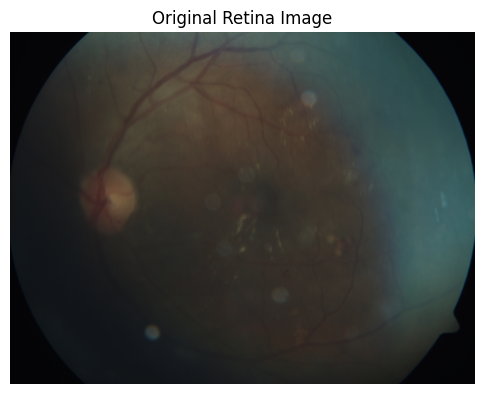

In [3]:
# ============================================
# LOAD IMAGE
# ============================================

image = cv2.imread(full_image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(6, 6))

plt.imshow(image_rgb)

plt.title("Original Retina Image")

plt.axis("off")

plt.show()

In [4]:
# ============================================
# DETECT IMAGE BLURRINESS
# ============================================

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

laplacian_var = cv2.Laplacian(
    gray,
    cv2.CV_64F
).var()

print("Blur Score:", laplacian_var)

# Interpretation
if laplacian_var < 100:

    print("Image is blurry")

else:

    print("Image is sufficiently sharp")

Blur Score: 12.911728406231475
Image is blurry


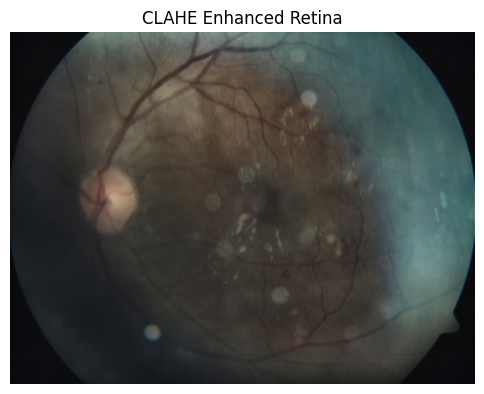

In [5]:
# ============================================
# APPLY CLAHE ENHANCEMENT
# ============================================

# Convert image to LAB color space
lab = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2LAB
)

# Split channels
l, a, b = cv2.split(lab)

# Create CLAHE object
clahe = cv2.createCLAHE(

    clipLimit=2.0,

    tileGridSize=(8, 8)
)

# Apply CLAHE on L channel
cl = clahe.apply(l)

# Merge channels
enhanced_lab = cv2.merge((cl, a, b))

# Convert back to BGR
enhanced_bgr = cv2.cvtColor(
    enhanced_lab,
    cv2.COLOR_LAB2BGR
)

# Convert BGR to RGB
enhanced_rgb = cv2.cvtColor(
    enhanced_bgr,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(6, 6))

plt.imshow(enhanced_rgb)

plt.title("CLAHE Enhanced Retina")

plt.axis("off")

plt.show()

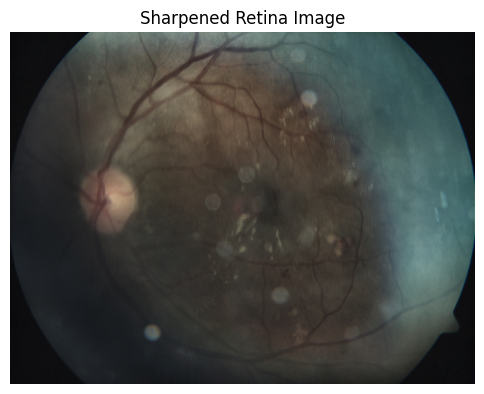

In [6]:
# ============================================
# APPLY MILD SHARPENING
# ============================================

kernel = np.array([

    [0, -1, 0],

    [-1, 5, -1],

    [0, -1, 0]
])

sharpened = cv2.filter2D(
    enhanced_rgb,
    -1,
    kernel
)

plt.figure(figsize=(6, 6))

plt.imshow(sharpened)

plt.title("Sharpened Retina Image")

plt.axis("off")

plt.show()

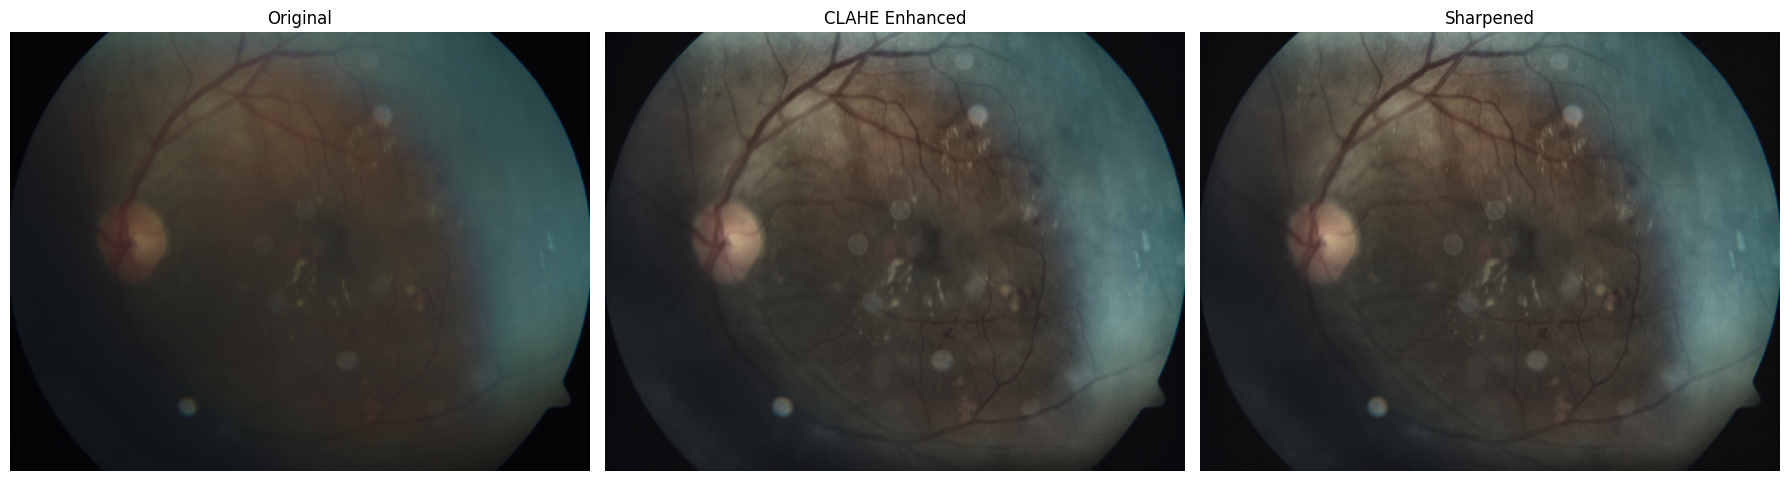

In [7]:
# ============================================
# COMPARE ORIGINAL VS ENHANCED
# ============================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# Original
axes[0].imshow(image_rgb)

axes[0].set_title("Original")

axes[0].axis("off")

# CLAHE
axes[1].imshow(enhanced_rgb)

axes[1].set_title("CLAHE Enhanced")

axes[1].axis("off")

# Sharpened
axes[2].imshow(sharpened)

axes[2].set_title("Sharpened")

axes[2].axis("off")

plt.tight_layout()

plt.show()

In [8]:
# ============================================
# CREATE ENHANCED DATASET FOLDERS
# ============================================

output_root = "../dataset"

enhanced_folders = [

    "enhanced_train",

    "enhanced_val",

    "enhanced_test"
]

classes = ["0", "1", "2", "3", "4"]

# Create folders
for folder in enhanced_folders:

    for class_name in classes:

        os.makedirs(

            os.path.join(
                output_root,
                folder,
                class_name
            ),

            exist_ok=True
        )

print("Enhanced dataset folders created!")

Enhanced dataset folders created!


In [9]:
# ============================================
# IMAGE ENHANCEMENT FUNCTION
# ============================================

def enhance_retina_image(image_path):

    # Load image
    image = cv2.imread(image_path)

    # Convert to LAB color space
    lab = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2LAB
    )

    # Split LAB channels
    l, a, b = cv2.split(lab)

    # Apply CLAHE
    clahe = cv2.createCLAHE(

        clipLimit=2.0,

        tileGridSize=(8, 8)
    )

    cl = clahe.apply(l)

    # Merge channels
    enhanced_lab = cv2.merge((cl, a, b))

    # Convert back to BGR
    enhanced_bgr = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2BGR
    )

    # ========================================
    # BLUR DETECTION
    # ========================================

    gray = cv2.cvtColor(
        enhanced_bgr,
        cv2.COLOR_BGR2GRAY
    )

    blur_score = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

    # ========================================
    # CONDITIONAL SHARPENING
    # ========================================

    if blur_score < 100:

        kernel = np.array([

            [0, -1, 0],

            [-1, 5, -1],

            [0, -1, 0]
        ])

        enhanced_bgr = cv2.filter2D(
            enhanced_bgr,
            -1,
            kernel
        )

    return enhanced_bgr

In [10]:
# ============================================
# PROCESS COMPLETE DATASET
# ============================================

dataset_pairs = [

    ("../dataset/train", "../dataset/enhanced_train"),

    ("../dataset/val", "../dataset/enhanced_val"),

    ("../dataset/test", "../dataset/enhanced_test")
]

for input_dir, output_dir in dataset_pairs:

    print(f"\nProcessing: {input_dir}")

    for class_name in classes:

        input_class_dir = os.path.join(
            input_dir,
            class_name
        )

        output_class_dir = os.path.join(
            output_dir,
            class_name
        )

        image_list = os.listdir(
            input_class_dir
        )

        for image_name in image_list:

            input_image_path = os.path.join(
                input_class_dir,
                image_name
            )

            output_image_path = os.path.join(
                output_class_dir,
                image_name
            )

            try:

                # Enhance image
                enhanced_image = enhance_retina_image(
                    input_image_path
                )

                # Save image
                cv2.imwrite(
                    output_image_path,
                    enhanced_image
                )

            except Exception as e:

                print(
                    f"Error processing {image_name}: {e}"
                )

    print(f"Completed: {input_dir}")

print("\nEnhanced dataset generation completed!")


Processing: ../dataset/train
Completed: ../dataset/train

Processing: ../dataset/val
Completed: ../dataset/val

Processing: ../dataset/test
Completed: ../dataset/test

Enhanced dataset generation completed!


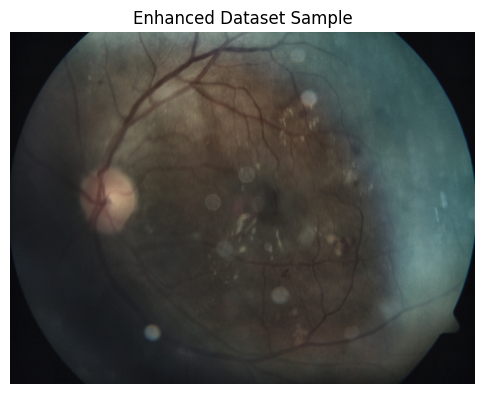

In [11]:
# ============================================
# VERIFY ENHANCED DATASET
# ============================================

sample_path = "../dataset/enhanced_train/2"

sample_image = os.listdir(sample_path)[0]

sample_image_path = os.path.join(
    sample_path,
    sample_image
)

enhanced_sample = cv2.imread(
    sample_image_path
)

enhanced_sample = cv2.cvtColor(
    enhanced_sample,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(6, 6))

plt.imshow(enhanced_sample)

plt.title("Enhanced Dataset Sample")

plt.axis("off")

plt.show()